<a href="https://colab.research.google.com/github/JakeEisner/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%204Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install category_encoders

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse
from category_encoders import TargetEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [ ]:
clinical_df = pd.read_csv("OmniCare_Clinical_Vitals.csv")
telemetry_df = pd.read_csv("OmniCare_Telemetry_Data.csv")

print("Clinical Vitals Data:")
display(clinical_df.head())

print("Telemetry Data:")
display(telemetry_df.head())


Clinical Vitals Data:


,Patient_ID,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,177.5,66.3,21.06,110.0,75.0
1,1001,167.9,57.5,20.39,115.0,79.0
2,1002,179.7,57.4,17.77,111.0,77.0
3,1003,192.8,80.9,21.76,122.0,88.0
4,1004,166.5,65.7,23.70,138.0,89.0


Telemetry Data:


,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34


# Phase 1: Causal Topology and Multicollinearity Forensics

## Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)

A likely omitted confounder is **poverty or low socioeconomic status**. Patients with lower income may be more likely to have a high-deductible insurance plan, and they may also be more likely to have higher inpatient admission rates because they delay preventative care or face barriers to treatment.

### DAG (Fork Structure)

```text
              Poverty / Low Socioeconomic Status
                      /                 \
                     v                   v
High_Deductible_Insurance_Plan   Inpatient_Admission_Rate

In [ ]:
# Step 1.2: The Variance Inflation Factor (VIF) Audit
# To diagnose multicollinearity among the continuous physiological predictors,
# I calculate the Variance Inflation Factor (VIF) for the following variables:
# Weight_kg, Height_cm, BMI, Systolic_BP, Diastolic_BP


In [ ]:
vif_features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]

vif_df = clinical_df[vif_features].dropna().copy()
X_vif = sm.add_constant(vif_df)

vif_results = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

print("Beginning VIF Results:")
display(vif_results)


Beginning VIF Results:


,Variable,VIF
0,const,3369.565806
1,Weight_kg,57.428058
2,Height_cm,28.419446
3,BMI,16.981232
4,Systolic_BP,4.219406
5,Diastolic_BP,4.219820


The initial VIF results identify whether any physiological predictor is excessively redundant. Because BMI is mechanically constructed from height and weight, it is a strong candidate for multicollinearity. To stabilize the feature set, I drop the most redundant variable and recalculate the VIF values.

In [ ]:
reduced_features = ["Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]

vif_df_reduced = clinical_df[reduced_features].dropna().copy()
X_vif_reduced = sm.add_constant(vif_df_reduced)

vif_results_reduced = pd.DataFrame({
    "Variable": X_vif_reduced.columns,
    "VIF": [variance_inflation_factor(X_vif_reduced.values, i) for i in range(X_vif_reduced.shape[1])]
})

print("Final VIF Results After Dropping BMI:")
display(vif_results_reduced)


Final VIF Results After Dropping BMI:


,Variable,VIF
0,const,321.090128
1,Weight_kg,3.763969
2,Height_cm,3.763812
3,Systolic_BP,4.219406
4,Diastolic_BP,4.219820


BMI is dropped because it is the most redundant physiological variable. After removing it, the recalculated VIF values show a more stable feature set, which reduces multicollinearity and improves the reliability of the regression architecture.

# Phase 2: Visual Forensics and The High-Cardinality Frontier

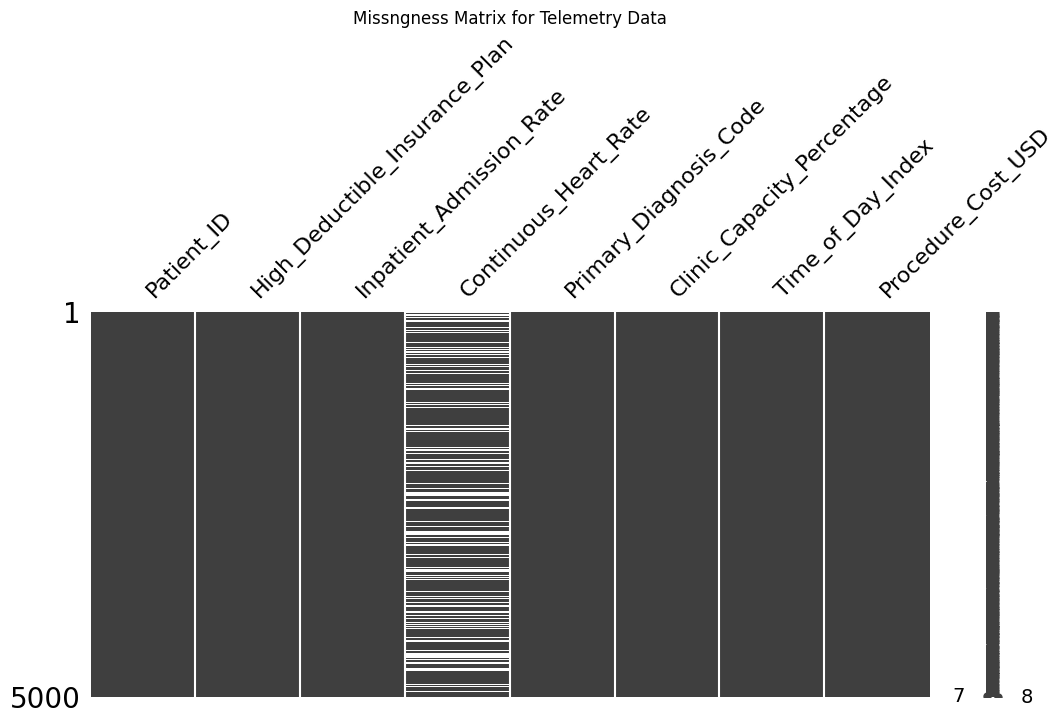

In [ ]:
### Step 2.1: The Architecture of Missingness

# To investigate the missing-data structure in the telemetry dataset, I generate
# a missingness matrix using the missingno library.

msno.matrix(telemetry_df, figsize=(12, 5))
plt.title("Missngness Matrix for Telemetry Data")
plt.show()

The missingness is MNAR because it depends on an unobserved factor (income). Lower-income patients are less likely to transmit data due to cost constraints. This is not MCAR because the missingness is systematic, and not MAR because it depends on an underlying mechanism tied to the missing values themselves. Mean imputation would bias the dataset by artificially compressing variation and masking real differences across patients.

In [ ]:
## Step 2.2: Escaping the Dummy Variable Trap

# The variable Primary_Diagnosis_Code contains 850 distinct ICD-10 diagnosis
# strings. A naive one-hot encoding approach would generate 850 dummy columns,
# one for each diagnosis category.

# Explanation: If Primary_Diagnosis_Code contains exactly 850 categories,
# then one-hot encoding creates 850 binary columns. For each patient, exactly
# one dummy variable equals 1 and the other 849 equal 0. This means the sum of
# all 850 diagnosis dummies is always exactly equal to 1 for every row.

# If a regression also includes a constant intercept term, then the intercept
# column is itself a column of all 1s. That creates the exact linear relationship:

# Intercept = D1 + D2 + D3 + ... + D850

This creates perfect multicollinearity, making the design matrix singular so (X'X)^{-1} cannot be computed.

In [ ]:
# Step 2.3: Target Encoding Implementation

'''
To avoid the issue of dimensionality and computational instability created by
850 dummy columns, I apply target encoding to Primary_Diagnosis_Code.
This replaces each diagnosis string with the historical mean of the target
variable, Procedure_Cost_USD.
'''

model_base = telemetry_df.dropna(subset=["Primary_Diagnosis_Code", "Procedure_Cost_USD"]).copy()

encoder = TargetEncoder(cols=["Primary_Diagnosis_Code"])
model_base["Target_Encoded_Diagnosis"] = encoder.fit_transform(model_base["Primary_Diagnosis_Code"], model_base["Procedure_Cost_USD"])

print("First 5 Rows of Target Encoded Diagnosis:")
display(model_base[["Primary_Diagnosis_Code", "Target_Encoded_Diagnosis"]].head())

First 5 Rows of Target Encoded Diagnosis:


,Primary_Diagnosis_Code,Target_Encoded_Diagnosis
0,J86.381,1707.697108
1,M29.789,1792.303198
2,E49.618,1730.334968
3,E66.244,1725.060944
4,J45.553,1801.821085


### Step 2.3 Interpretation

Target encoding compresses the high cardinality diagnosis variable into a single continuous numeric feature. This preserves useful predictive information while avoiding the explosion in dimensionality that would result from one-hot encoding hundreds of ICD-10 categories. It makes the final modeling pipeline much more computationally efficient and statistically stable.

# Phase 3: Architecting the Prediction Engine

## Step 3.1: OLS Optimization via Patsy Formulas

I now merge the sanitized telemetry features with the clinical vitals data and estimate an OLS model using `statsmodels.formula.api`. The dependent variable is `Procedure_Cost_USD`, and the predictors include: `Target_Encoded_Diagnosis`, `Clinic_Capacity_Percentage`, `Time_of_Day_Index`, `Weight_kg`, `Height_cm`, `Systolic_BP`, `Diastolic_BP`

In [ ]:
last_df = model_base.merge(clinical_df, on="Patient_ID")

last_df = last_df.dropna(subset=[
    "Procedure_Cost_USD",
    "Target_Encoded_Diagnosis",
    "Clinic_Capacity_Percentage",
    "Time_of_Day_Index",
    "Weight_kg",
    "Height_cm",
    "Systolic_BP",
    "Diastolic_BP"
])

print("Final analytical dataframe shape:", last_df.shape)
display(last_df.head())

Final analytical dataframe shape: (5000, 14)


,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD,Target_Encoded_Diagnosis,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84,1707.697108,177.5,66.3,21.06,110.0,75.0
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77,1792.303198,167.9,57.5,20.39,115.0,79.0
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19,1730.334968,179.7,57.4,17.77,111.0,77.0
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93,1725.060944,192.8,80.9,21.76,122.0,88.0
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34,1801.821085,166.5,65.7,23.70,138.0,89.0


In [ ]:
# FIt the OLS Model

formula = "Procedure_Cost_USD ~ Target_Encoded_Diagnosis + Clinic_Capacity_Percentage + Time_of_Day_Index + Weight_kg + Height_cm + Systolic_BP + Diastolic_BP"

ols_model = smf.ols(formula=formula, data=last_df).fit()

print("OLS Model Summary:")
print(ols_model.summary())

OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          6.83e-296
Time:                        15:03:58   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
I

### Step 3.1 Interpretation

This OLS model estimates procedure cost as a function of encoded diagnosis risk, clinic congestion, time of day, and patient physiological characteristics. Each coefficient measures the expected change in `Procedure_Cost_USD` associated with a one-unit increase in that predictor, holding the other included variables constant. This makes the pricing engine both interpretable and economically structured.

In [ ]:
# Step 3.2: Financial Loss Quantification (RMSE)

# Because R-squared is an abstract goodness-of-fit measure, I calculate the Root
# Mean Squared Error (RMSE) to quantify model error directly in US dollars.

predictions = ols_model.fittedvalues
actual_values = last_df["Procedure_Cost_USD"]
rmse_value = rmse(actual_values, predictions)

print("Root Mean Squared Error (RMSE):", rmse_value)

Root Mean Squared Error (RMSE): 334.80215211463116


### Step 3.2 Analysis

RMSE translates prediction error into the original unit of measurement, which here is US dollars. That makes it far more meaningful for management than R-squared because it shows the model’s typical pricing error in real financial terms.

If a typical outpatient MRI costs **1,200** and the algorithm produces an RMSE of **$450**, then the model is wrong by about **37.5% of the procedure’s value** on a typical prediction. That is operationally dangerous.

The operational risk is that hospitals would be making live pricing decisions using an unstable prediction engine. The financial risk is that underpricing would reduce revenue and overpricing could suppress demand, trigger disputes, and complicate reimbursement. The regulatory risk is even more serious because healthcare pricing is highly sensitive. Large unpredictable pricing errors could create fairness concerns, generate compliance scrutiny, and damage the credibility of the hospital network. A model with that level of pricing error would not be safe to deploy without major redesign and validation.

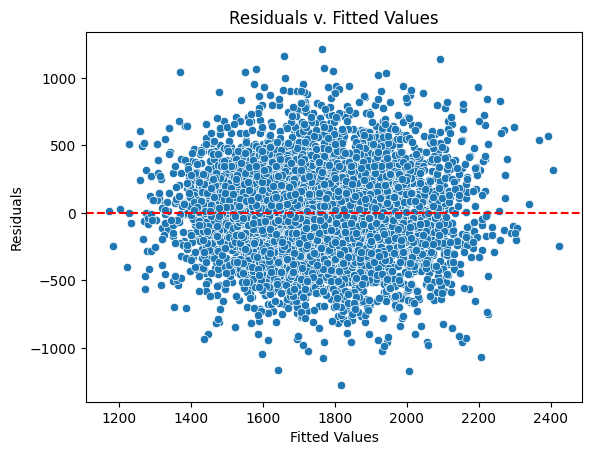

In [ ]:
# Step 3.3: Residual Diagnostics for Heteroscedasticity

residuals = ols_model.resid
fitted = ols_model.fittedvalues

sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0,color="red",linestyle = "--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals v. Fitted Values")
plt.show()

### Step 3.3 Analysis

If the residuals fan out as the fitted values increase, that would be evidence of **heteroscedasticity**, meaning the variance of the prediction errors is not constant across the cost distribution. In that case, the model would be less reliable for higher-cost procedures, which is especially concerning in surge-pricing environments.

If the residuals instead appear randomly scattered around zero with a roughly similar spread across fitted values, then there is no strong visual evidence of heteroscedasticity. That would suggest the model’s error variance is relatively stable across different pricing levels, making the OLS framework more credible.

# Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

## Task 4.1: Lagrange Multiplier Test for Heteroscedasticity

For this step, I used the P.R.I.M.E. prompting framework to direct an LLM to generate Python code for White’s Lagrange Multiplier Test for Heteroscedasticity using my exact OLS model.

### P.R.I.M.E. Prompt

**Persona:** You are an expert econometrics coding assistant with strong experience in Python, statsmodels, and regression diagnostics.

**Role:** Act as my technical partner for an econometrics assignment in Google Colab.

**Instructions:** Write Python code that runs White’s Lagrange Multiplier Test for Heteroscedasticity on my existing OLS regression model using `statsmodels.stats.diagnostic.het_white`. My fitted model object is named `ols_model`. Use the residuals and exogenous variables stored in that fitted model. Print the LM statistic, LM test p-value, F-statistic, and F-test p-value. Then print a short conclusion stating whether the null hypothesis of homoscedasticity is rejected at the 5% significance level.

**Meaning:** This test is being used to formally evaluate whether the residual variance in my pricing model is constant. The result matters because heteroscedasticity would weaken the reliability of standard OLS inference.

**Evaluation:** The code must be clean, runnable in Google Colab, use my exact model name `ols_model`, and produce clearly labeled output. Do not rebuild the regression model. Only use the already-fitted model object.

In [ ]:
from statsmodels.stats.diagnostic import het_white

white_test = het_white(ols_model.resid, ols_model.model.exog)

lm_stat = white_test[0]
lm_pvalue = white_test[1]
f_stat = white_test[2]
f_pvalue = white_test[3]

print("White's LM Statistic:", lm_stat)
print("White's LM Test p-value:", lm_pvalue)
print("White's F-Statistic:", f_stat)
print("White's F-Test p-value:", f_pvalue)

if lm_pvalue < 0.05:
    print("Conclusion: Reject the null hypothesis of homoscedasticity. There is evidence of heteroscedasticity.")
else:
    print("Conclusion: Fail to reject the null hypothesis of homoscedasticity. There is not sufficient evidence of heteroscedasticity.")

White's LM Statistic: 186.46773970660723
White's LM Test p-value: 1.4380291432919198e-22
White's F-Statistic: 5.494188406766981
White's F-Test p-value: 4.4790231228469927e-23
Conclusion: Reject the null hypothesis of homoscedasticity. There is evidence of heteroscedasticity.


The p-value from White’s LM test is effectively zero (p < 0.05), so I reject the null hypothesis of homoscedasticity. This indicates strong statistical evidence of heteroscedasticity in the model.